In [28]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
file_path_bc = '1738317691_BasicClubConvergence_20.json'  # Replace with your JSON file path
file_path_d = '1738317597_ConvergenceMitigationSavings_20.json'

#file_path_d = '1738285906_ConvergenceMitigationSavings_20_smooth.json' #cms 7 fc
#file_path_bc = "1738286270_BasicClubConvergence_20_smooth.json" #bc 7 fc
# Load JSON data for both datasets
with open(file_path_bc, 'r') as f:
    data_bc = json.load(f)

with open(file_path_d, 'r') as f:
    data_d = json.load(f)


In [29]:
len(data_bc), len(data_d)

(1660, 1669)

In [30]:
data_bc = [d for d in data_bc if "mitigation_rates_all_regions_region_0_variance" in d.keys()]
num_agents = 20

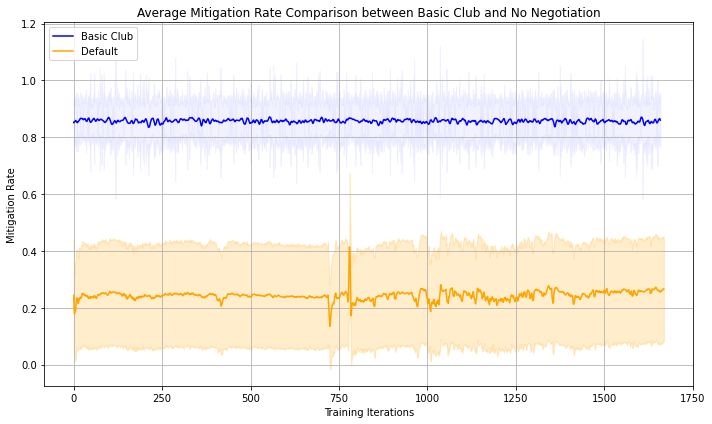

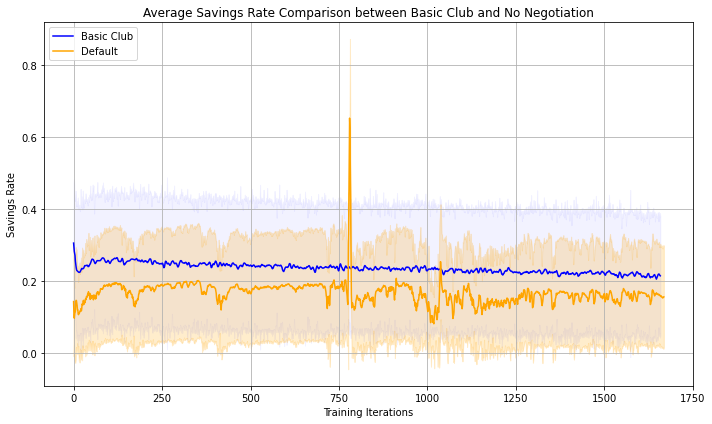

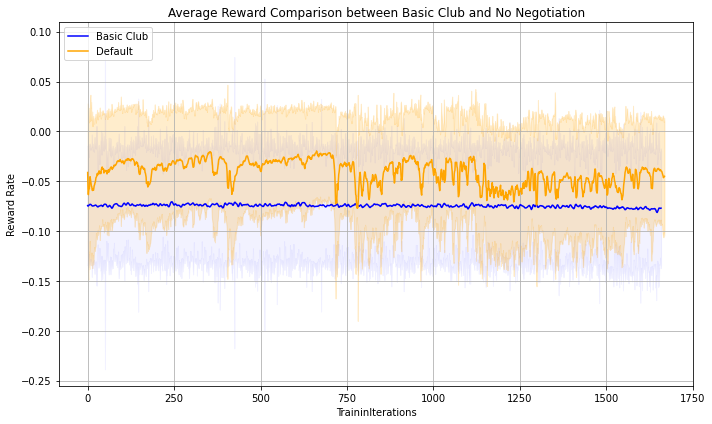

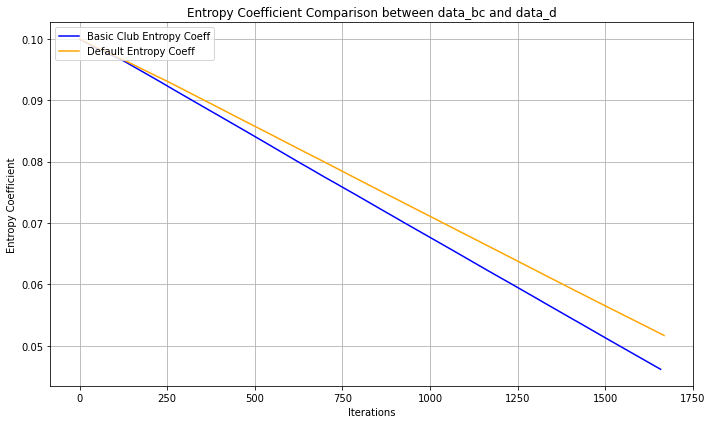

In [31]:
# Function to collect averages and variances for a specified metric
def collect_metrics(data, metric_prefix):
    mean_values = []
    variance_values = []
    
    for i in range(num_agents):
        mean_values.append([d[f'{metric_prefix}_all_regions_region_{i}_mean'] for d in data])
        variance_values.append([d[f'{metric_prefix}_all_regions_region_{i}_variance'] for d in data])
    
    # Calculate overall mean and variance
    overall_mean = pd.DataFrame(mean_values).mean().tolist()
    overall_variance = pd.DataFrame(variance_values).mean().tolist()
    overall_std_dev = [v ** 0.5 for v in overall_variance]
    
    return overall_mean, overall_variance, overall_std_dev

# Function to calculate rolling average
def rolling_average(data, window_size):
    return pd.Series(data).rolling(window=window_size, min_periods=1).mean().tolist()

# Collect metrics for both datasets
overall_mean_mitigation_bc, overall_variance_mitigation_bc, overall_std_dev_mitigation_bc = collect_metrics(data_bc, 'mitigation_rates')
overall_mean_mitigation_d, overall_variance_mitigation_d, overall_std_dev_mitigation_d = collect_metrics(data_d, 'mitigation_rates')

overall_mean_savings_bc, overall_variance_savings_bc, overall_std_dev_savings_bc = collect_metrics(data_bc, 'savings')
overall_mean_savings_d, overall_variance_savings_d, overall_std_dev_savings_d = collect_metrics(data_d, 'savings')

overall_mean_reward_bc, overall_variance_reward_bc, overall_std_dev_reward_bc = collect_metrics(data_bc, 'reward')
overall_mean_reward_d, overall_variance_reward_d, overall_std_dev_reward_d = collect_metrics(data_d, 'reward')

# Collecting entropy coefficients
entropy_coeff_bc = [d["learner_stats"]["entropy_coeff"] for d in data_bc]
entropy_coeff_d = [d["learner_stats"]["entropy_coeff"] for d in data_d]

# Function to plot metrics
def plot_metric_comparison(title, x_label, y_label, mean_bc, std_dev_bc, mean_d, std_dev_d, label_bc, label_d):
    plt.figure(figsize=(10, 6))
    
    # Rolling averages
    smoothed_mean_bc = rolling_average(mean_bc, window_size=5)
    smoothed_mean_d = rolling_average(mean_d, window_size=5)
    
    # Plot for data_bc
    plt.plot(smoothed_mean_bc, label=label_bc, color='blue')
    plt.fill_between(range(len(smoothed_mean_bc)), 
                     [m - s for m, s in zip(smoothed_mean_bc, std_dev_bc)],
                     [m + s for m, s in zip(smoothed_mean_bc, std_dev_bc)],
                     color='blue', alpha=0.05)

    # Plot for data_d
    plt.plot(smoothed_mean_d, label=label_d, color='orange')
    plt.fill_between(range(len(smoothed_mean_d)), 
                     [m - s for m, s in zip(smoothed_mean_d, std_dev_d)],
                     [m + s for m, s in zip(smoothed_mean_d, std_dev_d)],
                     color='orange', alpha=0.2)

    # Adding titles and labels
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# Plotting Mitigation Rates
plot_metric_comparison(
    title='Average Mitigation Rate Comparison between Basic Club and No Negotiation',
    x_label='Training Iterations',
    y_label='Mitigation Rate',
    mean_bc=overall_mean_mitigation_bc,
    std_dev_bc=overall_std_dev_mitigation_bc,
    mean_d=overall_mean_mitigation_d,
    std_dev_d=overall_std_dev_mitigation_d,
    label_bc='Basic Club',
    label_d='Default'
)

# Plotting Savings Rates
plot_metric_comparison(
    title='Average Savings Rate Comparison between Basic Club and No Negotiation',
    x_label='Training Iterations',
    y_label='Savings Rate',
    mean_bc=overall_mean_savings_bc,
    std_dev_bc=overall_std_dev_savings_bc,
    mean_d=overall_mean_savings_d,
    std_dev_d=overall_std_dev_savings_d,
    label_bc='Basic Club',
    label_d='Default'
)

# Plotting Reward Rates
plot_metric_comparison(
    title='Average Reward Comparison between Basic Club and No Negotiation',
    x_label='TraininIterations',
    y_label='Reward Rate',
    mean_bc=overall_mean_reward_bc,
    std_dev_bc=overall_std_dev_reward_bc,
    mean_d=overall_mean_reward_d,
    std_dev_d=overall_std_dev_reward_d,
    label_bc='Basic Club',
    label_d='Default'
)

# Plotting Entropy Coefficient
plt.figure(figsize=(10, 6))
plt.plot(entropy_coeff_bc, label='Basic Club Entropy Coeff', color='blue')
plt.plot(entropy_coeff_d, label='Default Entropy Coeff', color='orange')
plt.title('Entropy Coefficient Comparison between data_bc and data_d')
plt.xlabel('Iterations')
plt.ylabel('Entropy Coefficient')
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
import json
import matplotlib.pyplot as plt
import pandas as pd
# Load JSON data from a file
file_path_bc = '1738179751_BasicClubTariffAmbition_7.json'  # Replace with your JSON file path
file_path_d = '1738179630_ConvergenceMitigationSavings_7.json'
with open(file_path_bc, 'r') as f:
    data_bc = json.load(f)
with open(file_path_d, 'r') as f:
    data_d = json.load(f)
num_agents = int(file_path_bc.split("_")[2].replace(".json",""))


In [6]:
metrics_ = []
for data in [data_bc, data_d]:
    # Define metrics with mean, variance values
    metrics = {
        "temperature_rise": {
            "mean": [d["temperature_rise_mean"] for d in data],
            "variance": [d["temperature_rise_variance"][0] for d in data]
        },
        "mitigation_means": {
            f'region_{i}': {
                "mean": [d[f'mitigation_rates_all_regions_region_{i}_mean'] for d in data],
                "variance": [d[f'mitigation_rates_all_regions_region_{i}_variance'] for d in data]
            } for i in range(num_agents)
        },
        "utility_means": {
            f'region_{i}': {
                "mean": [d[f'utility_all_regions_region_{i}_mean'] for d in data],
                "variance": [d[f'utility_all_regions_region_{i}_variance'] for d in data]
            } for i in range(num_agents)
        },
        "damages_means": {
            f'region_{i}': {
                "mean": [d[f'damages_all_regions_region_{i}_mean'] for d in data],
                "variance": [d[f'damages_all_regions_region_{i}_variance'] for d in data]
            } for i in range(num_agents)
        },
        "reward_means": {
            f'region_{i}': {
                "mean": [d[f'reward_all_regions_region_{i}_mean'] for d in data],
                "variance": [d[f'reward_all_regions_region_{i}_variance'] for d in data]
            } for i in range(num_agents)
        },
        "savings_means": {
            f'region_{i}': {
                "mean": [d[f'savings_all_regions_region_{i}_mean'] for d in data],
                "variance": [d[f'savings_all_regions_region_{i}_variance'] for d in data]
            } for i in range(num_agents)
        },
        # Add learner stats
        "learner_entropy_coeff": {
            "mean": [d["learner_stats"]["entropy_coeff"] for d in data]
        },
        "policy_entropy": {
            "mean": [d["learner_stats"]["policy_entropy"] for d in data]
        }
    }
    metrics_.append(metrics)
metrics_bc, metrics_d = metrics_

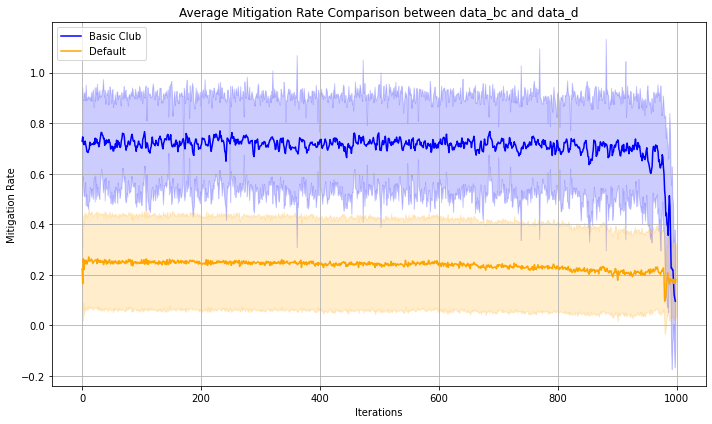

In [12]:
# Collecting average mitigation rates and their variance for data_bc
mean_mitigation_bc = []
variance_mitigation_bc = []

for i in range(num_agents):
    mean_mitigation_bc.append([d[f'mitigation_rates_all_regions_region_{i}_mean'] for d in data_bc])
    variance_mitigation_bc.append([d[f'mitigation_rates_all_regions_region_{i}_variance'] for d in data_bc])

# Calculate overall mean and variance for data_bc
overall_mean_mitigation_bc = pd.DataFrame(mean_mitigation_bc).mean().tolist()
overall_variance_mitigation_bc = pd.DataFrame(variance_mitigation_bc).mean().tolist()
overall_std_dev_mitigation_bc = [v ** 0.5 for v in overall_variance_mitigation_bc]

# Collecting average mitigation rates and their variance for data_d
mean_mitigation_d = []
variance_mitigation_d = []

for i in range(num_agents):
    mean_mitigation_d.append([d[f'mitigation_rates_all_regions_region_{i}_mean'] for d in data_d])
    variance_mitigation_d.append([d[f'mitigation_rates_all_regions_region_{i}_variance'] for d in data_d])

# Calculate overall mean and variance for data_d
overall_mean_mitigation_d = pd.DataFrame(mean_mitigation_d).mean().tolist()
overall_variance_mitigation_d = pd.DataFrame(variance_mitigation_d).mean().tolist()
overall_std_dev_mitigation_d = [v ** 0.5 for v in overall_variance_mitigation_d]

# Plotting
plt.figure(figsize=(10, 6))

# Plot for data_bc
plt.plot(overall_mean_mitigation_bc, label='Basic Club', color='blue')
plt.fill_between(range(len(overall_mean_mitigation_bc)), 
                 [m - s for m, s in zip(overall_mean_mitigation_bc, overall_std_dev_mitigation_bc)],
                 [m + s for m, s in zip(overall_mean_mitigation_bc, overall_std_dev_mitigation_bc)],
                 color='blue', alpha=0.2)

# Plot for data_d
plt.plot(overall_mean_mitigation_d, label='Default', color='orange')
plt.fill_between(range(len(overall_mean_mitigation_d)), 
                 [m - s for m, s in zip(overall_mean_mitigation_d, overall_std_dev_mitigation_d)],
                 [m + s for m, s in zip(overall_mean_mitigation_d, overall_std_dev_mitigation_d)],
                 color='orange', alpha=0.2)

# Adding titles and labels
plt.title('Average Mitigation Rate Comparison between Basic Club and No Negotiation')
plt.xlabel('Iterations')
plt.ylabel('Mitigation Rate')
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

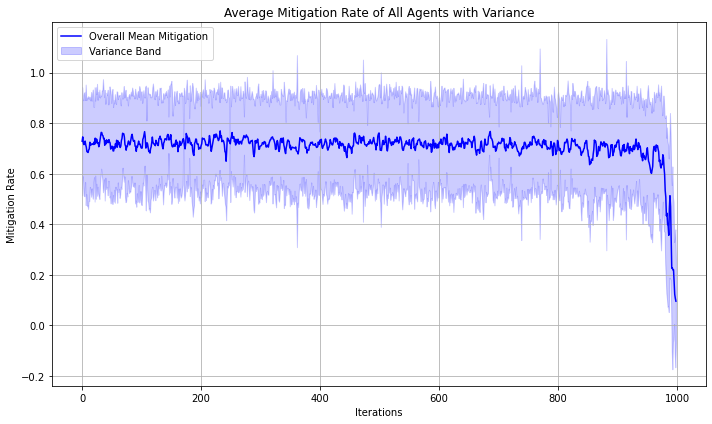

In [9]:
# Collecting average mitigation rates and their variance
mean_mitigation = []
variance_mitigation = []

for i in range(num_agents):
    mean_mitigation.append([d[f'mitigation_rates_all_regions_region_{i}_mean'] for d in data_bc])
    variance_mitigation.append([d[f'mitigation_rates_all_regions_region_{i}_variance'] for d in data_bc])
# Calculate overall mean and variance across all regions
overall_mean_mitigation = pd.DataFrame(mean_mitigation).mean().tolist()
overall_variance_mitigation = pd.DataFrame(variance_mitigation).mean().tolist()
overall_std_dev_mitigation = [v ** 0.5 for v in overall_variance_mitigation]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(overall_mean_mitigation, label='Overall Mean Mitigation', color='blue')
plt.fill_between(range(len(overall_mean_mitigation)), 
                 [m - s for m, s in zip(overall_mean_mitigation, overall_std_dev_mitigation)],
                 [m + s for m, s in zip(overall_mean_mitigation, overall_std_dev_mitigation)],
                 color='blue', alpha=0.2, label='Variance Band')

plt.title('Average Mitigation Rate of All Agents with Variance')
plt.xlabel('Iterations')
plt.ylabel('Mitigation Rate')
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()